# Seismic Refraction Processing 
## Howelson Hill, Steamboat Springs, CO

### Molly Bilhartz, Samantha Lopez, Tessa Murphy

In [11]:
# files = [
#     "../../data/ns_seismic/raw_data/03.dat", "../../data/ns_seismic/raw_data/04.dat", "../../data/ns_seismic/raw_data/05.dat", "../../data/ns_seismic/raw_data/06.dat",
#     "../../data/ns_seismic/raw_data/07.dat", "../../data/ns_seismic/raw_data/08.dat", "../../data/ns_seismic/raw_data/09.dat", "../../data/ns_seismic/raw_data/10.dat",
#     "../../data/ns_seismic/raw_data/11.dat", "../../data/ns_seismic/raw_data/12.dat", "../../data/ns_seismic/raw_data/13.dat", "../../data/ns_seismic/raw_data/14.dat",
#     "../../data/ns_seismic/raw_data/15.dat", "../../data/ns_seismic/raw_data/16.dat", "../../data/ns_seismic/raw_data/17.dat", "../../data/ns_seismic/raw_data/18.dat"
# ]

In [24]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

# Path from Working ipynb files -> PY files
sys.path.append(str(Path.cwd().parent / "PY files"))

from AG_lib.geodata import SeismicGather, geodata

# -----------------------------
# File paths
# -----------------------------
from pathlib import Path

data_dir = Path("../../data/ns_seismic/raw_data")

files = sorted(data_dir.glob("*.dat"))

print(files)

[PosixPath('../../data/ns_seismic/raw_data/03.dat'), PosixPath('../../data/ns_seismic/raw_data/04.dat'), PosixPath('../../data/ns_seismic/raw_data/05.dat'), PosixPath('../../data/ns_seismic/raw_data/06.dat'), PosixPath('../../data/ns_seismic/raw_data/07.dat'), PosixPath('../../data/ns_seismic/raw_data/08.dat'), PosixPath('../../data/ns_seismic/raw_data/09.dat'), PosixPath('../../data/ns_seismic/raw_data/10.dat'), PosixPath('../../data/ns_seismic/raw_data/11.dat'), PosixPath('../../data/ns_seismic/raw_data/12.dat'), PosixPath('../../data/ns_seismic/raw_data/13.dat'), PosixPath('../../data/ns_seismic/raw_data/14.dat'), PosixPath('../../data/ns_seismic/raw_data/15.dat'), PosixPath('../../data/ns_seismic/raw_data/16.dat'), PosixPath('../../data/ns_seismic/raw_data/17.dat'), PosixPath('../../data/ns_seismic/raw_data/18.dat')]


In [25]:
# -----------------------------
# SEG-2 DAT reader
# -----------------------------

def load_seg2_shot(filename):
    st = read(str(filename))

    g = SeismicGather()
    g.data = []

    sx = float(st[0].stats.seg2["SOURCE_LOCATION"])

    for tr in st:
        seg2 = tr.stats.seg2

        rx = float(seg2["RECEIVER_LOCATION"])
        chan = int(seg2["CHANNEL_NUMBER"])

        rec = geodata(
            sx=sx,
            rx=rx,
            offset=rx - sx,
            delta_t=float(tr.stats.delta),
            data=np.asarray(tr.data, dtype=float),
            name=f"{Path(filename).name}_ch{chan}"
        )

        rec.chan = chan
        rec.stack = int(seg2.get("STACK", 1))

        g.data.append(rec)

    g.sx = sx
    g.filename = Path(filename).name

    return g.sort_by_offset()

In [17]:
from obspy import read

st = read(files[0])

print(st)

for tr in st[:5]:
    print(tr)

48 Trace(s) in Stream:

... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples
...
(46 other traces)
...
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples
... | 2026-05-24T12:21:32.000000Z - 2026-05-24T12:21:33.999875Z | 8000.0 Hz, 16000 samples


In [21]:
st = read(files[0])

for i in range(10):
    print(
        i+1,
        st[i].stats.seg2["CHANNEL_NUMBER"],
        st[i].stats.seg2["RECEIVER_LOCATION"]
    )

1 1 0.00
2 2 2.00
3 3 4.00
4 4 6.00
5 5 8.00
6 6 10.00
7 7 12.00
8 8 14.00
9 9 16.00
10 10 18.00


In [26]:
# -----------------------------
# Load all shot gathers
# -----------------------------

shots = {}

for f in files:
    g = load_seg2_shot(f)
    shots[f.name] = g

    print(
        f.name,
        "source =", g.sx,
        "m | traces =", len(g.data),
        "| dt =", g.data[0].delta_t,
        "s"
    )

03.dat source = 0.0 m | traces = 48 | dt = 0.000125 s
04.dat source = 6.0 m | traces = 48 | dt = 0.000125 s
05.dat source = 12.0 m | traces = 48 | dt = 0.000125 s
06.dat source = 18.0 m | traces = 48 | dt = 0.000125 s
07.dat source = 24.0 m | traces = 48 | dt = 0.000125 s
08.dat source = 30.0 m | traces = 48 | dt = 0.000125 s
09.dat source = 36.0 m | traces = 48 | dt = 0.000125 s
10.dat source = 42.0 m | traces = 48 | dt = 0.000125 s
11.dat source = 48.0 m | traces = 48 | dt = 0.000125 s
12.dat source = 54.0 m | traces = 48 | dt = 0.000125 s
13.dat source = 60.0 m | traces = 48 | dt = 0.000125 s
14.dat source = 66.0 m | traces = 48 | dt = 0.000125 s
15.dat source = 72.0 m | traces = 48 | dt = 0.000125 s
16.dat source = 78.0 m | traces = 48 | dt = 0.000125 s
17.dat source = 84.0 m | traces = 48 | dt = 0.000125 s
18.dat source = 90.0 m | traces = 48 | dt = 0.000125 s


<Figure size 1400x800 with 0 Axes>

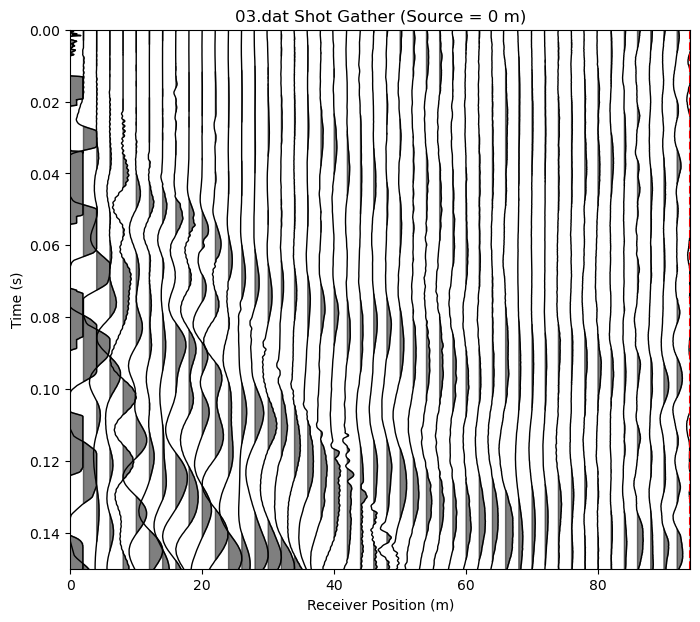

In [28]:
# wiggle plot at the first shot (03.dat)

shot03 = load_seg2_shot(data_dir / "03.dat")

plt.figure(figsize=(14,8))

shot03.wiggle_plot(
    xaxis="rx",
    scale=2.0
)

plt.title("03.dat Shot Gather (Source = 0 m)")
plt.xlabel("Receiver Position (m)")
plt.ylabel("Time (s)")
plt.xlim(0, 94)
plt.ylim(0.15, 0.00)

plt.axvline(94, color="red", linestyle="--")
plt.show()

<Figure size 1400x800 with 0 Axes>

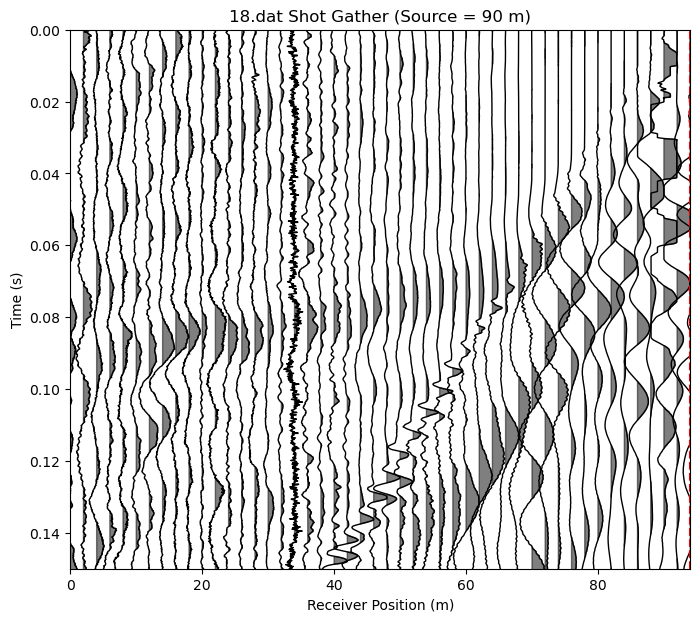

In [29]:
# wiggle plot at last shot (18.dat)

shot18 = load_seg2_shot(data_dir / "18.dat")

plt.figure(figsize=(14,8))

shot18.wiggle_plot(
    xaxis="rx",
    scale=2.0
)

plt.title("18.dat Shot Gather (Source = 90 m)")
plt.xlabel("Receiver Position (m)")
plt.ylabel("Time (s)")
plt.xlim(0, 94)
plt.ylim(0.15, 0.00)

plt.axvline(94, color="red", linestyle="--")
plt.show()

## first arrival picking and travel time curves

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from scipy.signal import butter, filtfilt

# -----------------------------
# Load a SEG-2 shot
# -----------------------------

def read_seg2_matrix(filename):
    st = read(str(filename))

    data = np.array([tr.data.astype(float) for tr in st])  # shape: traces x samples
    data = data.T  # shape: samples x traces

    dt = st[0].stats.delta
    t = np.arange(data.shape[0]) * dt

    rx = np.array([float(tr.stats.seg2["RECEIVER_LOCATION"]) for tr in st])
    sx = float(st[0].stats.seg2["SOURCE_LOCATION"])

    offsets = rx - sx

    return data, t, rx, sx, offsets

In [33]:
# -----------------------------
# Basic preprocessing
# -----------------------------

def bandpass_data(data, dt, fmin=20, fmax=200, order=4):
    fs = 1 / dt
    nyq = fs / 2

    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, data, axis=0)

def agc_data(data):
    out = data.copy().astype(float)

    for i in range(out.shape[1]):
        scale = np.sqrt(np.mean(out[:, i] ** 2))
        if scale == 0:
            scale = 1
        out[:, i] /= scale

    return out

In [36]:
# -----------------------------
# Image display: easier than wiggles for first breaks
# -----------------------------

def plot_gather_image(data, t, rx, sx, title="", tmax=0.16):
    vmax = np.percentile(np.abs(data), 99)

    plt.figure(figsize=(12, 7))
    plt.imshow(
        data,
        aspect="auto",
        cmap="gray",
        extent=[rx.min(), rx.max(), t[-1], t[0]],
        vmin=-vmax,
        vmax=vmax
    )

    plt.ylim(tmax, 0)
    plt.xlabel("Receiver position (m)")
    plt.ylabel("Time (s)")
    plt.title(title)
    plt.legend()
    plt.show()

/var/folders/lx/bjmg_9nd62z3tvrszw3rrpw00000gn/T/ipykernel_19434/2806113103.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


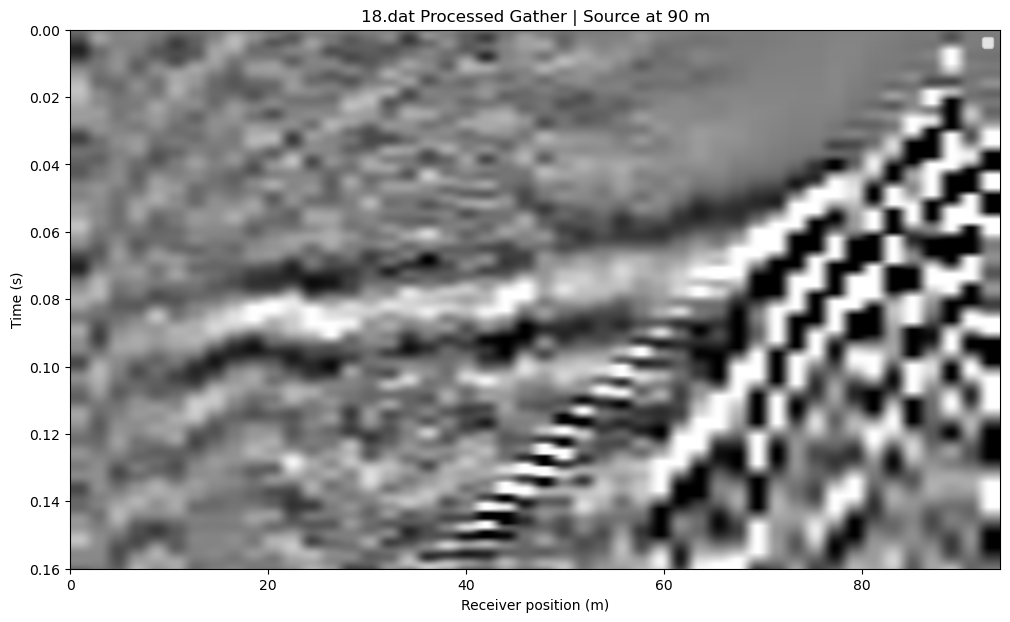

In [37]:
# -----------------------------
# Load and plot 18.dat
# -----------------------------

data18, t18, rx18, sx18, offsets18 = read_seg2_matrix(data_dir / "18.dat")

data18_filt = bandpass_data(data18, t18[1] - t18[0], fmin=20, fmax=200)
data18_proc = agc_data(data18_filt)

plot_gather_image(
    data18_proc,
    t18,
    rx18,
    sx18,
    title="18.dat Processed Gather | Source at 90 m",
    tmax=0.16
)